In [ ]:
using PhDProject
using JLD2
using ITensors

In [ ]:
function ohmic_spectral_function(w,s,ωc,α,β,thermal_chain_number)
    
    n = 1 ./(exp.(β*w).-1) #Bosonic occupation number
    if thermal_chain_number == 1
        renorm = 1 .+ n
    elseif thermal_chain_number == 2
        renorm = n
    end

    support = exp.(-w/ωc)
    ρ = (w.^(s) .*support).*renorm
    J =  α*(ωc^(1-s))*ρ
    replace_nan(J)
    return J
end
function ohmic_chain_mapping(thermal_chain_number,N_bath,ωc,s,α,β,D;kwargs...)

    N_chain = get(kwargs,:N_chain,N_bath)
    @assert(N_chain <= N_bath)

    couplings,energies = complex(zeros(N_bath)),complex(zeros(N_bath))
    spec_fun(t) = ohmic_spectral_function(t,s,ωc,α,β,thermal_chain_number)
    supp = (0,D)
    my_meas = PhDProject.Measure("my_meas", spec_fun, supp, false, Dict())
    my_op = PhDProject.OrthoPoly("my_op", N_chain-1, my_meas; Nquad=100000);
    α_coeffs,β_coeffs = PhDProject.coeffs(my_op)[:,1],PhDProject.coeffs(my_op)[:,2]
        

    if length(α_coeffs)<N_bath
        energies[1:N_chain] = α_coeffs
        couplings[1:N_chain] = sqrt.(β_coeffs)
        energies[N_chain+1:end] .= α_coeffs[N_chain]
        couplings[N_chain+1:end] .= sqrt(β_coeffs[N_chain])
    else
        energies = α_coeffs
        couplings = sqrt.(β_coeffs)
    end
    return energies,couplings
end
function initialise_choi_state(modes)
    #ψ_init = PhDProject.MPS(ComplexF64,modes,"0")

    gates = PhDProject.ITensor[]

    for i=1:N_ring
        sys = 2*i-1
        anc = 2*i
 
        # Hadamard on system qubit
        push!(gates, PhDProject.op("H", modes[sys]))

        # CNOT: control = system, target = ancilla
        push!(gates, PhDProject.op("CNOT", modes[sys], modes[anc]))
    end
    return gates
end
function initialise_setup(N_ring,J,B,compute_maps_bool,N_bath,ωc,s,α,β,D;kwargs...)
        
    if compute_maps_bool ==true
        qS = 1:2:(2*N_ring)
        qA = 2:2:(2*N_ring)
        q = 1:2*N_ring
    else
        qS = 1:N_ring
        q = qS
    end

    #Creating chain coefficients
    energies_1,couplings_1 = ohmic_chain_mapping(1,N_bath,ωc,s,α,β,D;kwargs...)
    energies_2,couplings_2 = ohmic_chain_mapping(2,N_bath,ωc,s,α,β,D;kwargs...)

    ##Creating indices
    sys_modes = PhDProject.siteinds("S=1/2",q[end])
    bath_modes = PhDProject.siteinds("Boson",2*N_bath)
    modes = [sys_modes;bath_modes]

    MPO_terms = PhDProject.OpSum()
    #Create system hamiltonian MPO terms
    for i =1:N_ring
        MPO_terms += B,"Sz",qS[i]
        if i <N_ring
            MPO_terms += J,"Sx",qS[i],"Sx",qS[i+1]
            MPO_terms += J,"Sy",qS[i],"Sy",qS[i+1]
        else
            @assert(i==N_ring)
            MPO_terms += J,"Sx",qS[i],"Sx",qS[1]
            MPO_terms += J,"Sy",qS[i],"Sy",qS[1]
        end
    end

    #Create Chain mapping MPO terms
    for i=1:N_bath
        MPO_terms += energies_1[i],"Adag",q[end]+(2*i-1),"A",q[end]+(2*i-1) ##energies for chain 1
        MPO_terms -= energies_2[i],"Adag",q[end]+(2*i),"A",q[end]+(2*i) ##energies for chain 2

        if i <N_bath
            MPO_terms += couplings_1[i+1],"Adag",q[end]+(2*i-1),"A",q[end]+(2*i+1) ##hopping site i to i+1 (chain 1)
            MPO_terms += conj(couplings_1[i+1]),"Adag",q[end]+(2*i+1),"A",q[end]+(2*i-1) ##hopping site i+1 to i (chain 1)

            MPO_terms -= couplings_2[i+1],"Adag",q[end]+(2*i),"A",q[end]+(2*i+2) ##hopping site i to i+1 (chain 2)
            MPO_terms -= conj(couplings_2[i+1]),"Adag",q[end]+(2*i+2),"A",q[end]+(2*i) ##hopping site i+1 to i (chain 2)
        end
    end

    #Create coupling MPO term
    MPO_terms += couplings_1[1],"Sx",qS[N_ring],"A",q[end]+1
    MPO_terms += couplings_1[1],"Sx",qS[N_ring],"Adag",q[end]+1

    MPO_terms -= couplings_2[1],"Sx",qS[N_ring],"A",q[end]+2
    MPO_terms -= couplings_2[1],"Sx",qS[N_ring],"Adag",q[end]+2
    #Create MPO
    H_MPO = PhDProject.MPO(MPO_terms,modes)

    #Create initial state
    if compute_maps_bool
        psi = PhDProject.MPS(ComplexF64,modes,"0")
        gates = initialise_choi_state(modes)
        psi = PhDProject.apply(gates,psi)
    else 

        # Initial product state
        state = Vector{String}(undef, N_ring + 2*N_bath)

        # Qubits: |0>|+>|->|0>
        state[1] = "Up"
        state[2] = "X+"
        state[3] = "X-"
        state[4] = "Up"

        # Bosons: vacuum
        for j in 1:2*N_bath
            state[N_ring + j] = "0"
        end

        psi = PhDProject.productMPS(modes, state)
    end

    return psi,H_MPO,modes,q,qA,qS
end
function calculateDynamicalMap(psi,N_ring)
    PhDProject.orthogonalize!(psi, 1)

    s_vec = [PhDProject.siteind(psi, i) for i=1:2*N_ring]
    θ = PhDProject.prod(psi[1:2*N_ring])
    ρAS = PhDProject.prime(θ, s_vec) * PhDProject.dag(θ) # reduced density matrix of system and reference, with primed indices for output legs

    d = PhDProject.NDTensors.dim(s_vec[1])^N_ring
    Cs = PhDProject.combiner(reverse(s_vec[1:2:end])) # Combiner tensor for merging system legs into a fat index
    Ca = PhDProject.combiner(reverse(s_vec[2:2:end])) # Combiner tensor for merging ancilla legs into a fat index


    ρΛ = ρAS*PhDProject.dag(Cs)*Cs'*PhDProject.dag(Ca)*Ca'# Merge physical legs to form a density matrix

    Css = PhDProject.combiner([inds(Cs)[1]',PhDProject.dag(inds(Cs)[1])])
    Caa = PhDProject.combiner([inds(Ca)[1]',PhDProject.dag(inds(Ca)[1])])
    Csa = PhDProject.combiner([inds(Cs)[1],PhDProject.inds(Ca)[1]])
    ρmat = ρΛ*PhDProject.dag(Csa)*Csa'
    ρmat = Matrix(ρmat,inds(ρmat));
    
    # message,bool = ρ_test(ρmat,cutoff)
    # if bool
    #     error(message)
    # end
    Λ = d*ρΛ*Css*Caa
    Λ = conj(Matrix(Λ,inds(Λ)));
    return Λ
end

#spin ring parameters
N_ring = 3
J = 1
B = 2
compute_maps_bool = true

#Chain mapping parameters
N_bath = 150
N_chain = 50
ωc = 1 # exponential cutoff
s = 1 #ohmicity
α = 0.5 #coupling strength
β = 10 #inverse temperature
D = 1 #bandwidth

#tdvp_parameters
tdvp_cutoff = 1e-10 #Numerical cutoff for tdvp
minbonddim = 5      #Minimum bond dimension for tdvp 
maxbonddim = 30       #Maximum bond dimension for tdvp
δt = 0.02            #Time step
T = 30               #Evolution time
TDVP_nsite = 2
times = range(δt,stop = T,step = δt)

# Enrichment parameters
# T_enrich = 0                #Time in simulation where enrichment is used
# Kr_cutoff = 1e-10 #Numerical cutoff used for Krylov enrichment
# k1 = 3                     #Number of Krylov states used
# τ_Krylov = 1


psi,H_MPO,modes,q,qA,qS = initialise_setup(N_ring,J,B,compute_maps_bool,N_bath,ωc,s,α,β,D;N_chain)
@show(PhDProject.norm(psi))

TDVP_nsite == 1 && growMPS!(ψ, minbonddim)

obs = PhDProject.Observer(
"times" => current_time,
"σz" => measure_pauli_z, 
"σx" => measure_pauli_x, 
"σy" => measure_pauli_y, 
"SvN" => measure_SvN)

Λ_vec = Vector{Any}(undef,length(times))
PhDProject.ITensors.set_warn_order(17)
for i=1:length(times)
    psi = PhDProject.tdvp(H_MPO, -im * δt, psi; time_step = -im * δt, cutoff = tdvp_cutoff, 
    mindim = minbonddim, maxdim = maxbonddim, outputlevel = 1, 
    observer! = obs, nsite = TDVP_nsite)
    @time Λ_vec[i] = calculateDynamicalMap(psi,N_ring)
end
    

σx_1 = [obs.σx[i][1] for i=1:length(obs.σx)]
σx_2 = [obs.σx[i][2] for i=1:length(obs.σx)]
σx_3 = [obs.σx[i][3] for i=1:length(obs.σx)]
σx_4 = [obs.σx[i][4] for i=1:length(obs.σx)]
PhDProject.Plots.plot(times,σx_1,label="site 1")
PhDProject.Plots.plot!(times,σx_2,label="site 2")
PhDProject.Plots.plot!(times,σx_3,label="site 3")
PhDProject.Plots.plot!(times,σx_4,label="site 4")

save_object("maps.jld2",Λ_vec)

PhDProject.norm(psi) = 0.9999999999999999
After sweep 1: maxlinkdim=6 maxerr=3.91E-11 current_time=0.0 - 0.02im time=0.307
  0.179072 seconds (212.23 k allocations: 11.497 MiB, 98.97% compilation time)
After sweep 1: maxlinkdim=8 maxerr=7.38E-14 current_time=0.0 - 0.02im time=5.977


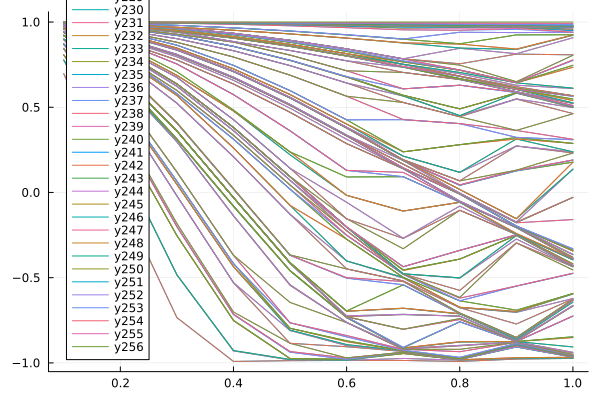

In [22]:
# spectra_Λ = complex(zeros(length(Λ_vec),2^(2*N_ring)))
# [spectra_Λ[i,:] = eigen(Λ_vec[i]).values for i=1:length(Λ_vec)] 
PhDProject.Plots.plot(times,real.(spectra_Λ))

In [47]:
#ψ_weak_coupling,obs_weak_couplng = ψ,obs;

In [46]:
#ψ_strong_coupling,obs_strong_couplng = ψ,obs;

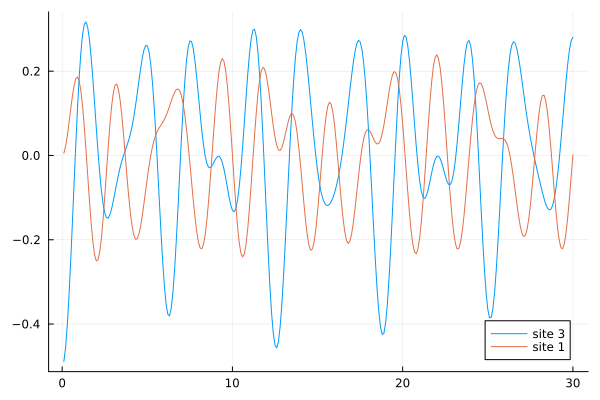

In [41]:
# times = range(δt,stop = T,step = δt)
σx_3 = [obs.σx[i][2] for i=1:length(obs.σx)]
σx_1 = [obs.σx[i][1] for i=1:length(obs.σx)]
PhDProject.Plots.plot(times,σx_3,label="site 3")
PhDProject.Plots.plot!(times,σx_1,label="site 1")